Device: cuda | Dataset: /kaggle/input/datasets/balraj98/modelnet40-princeton-3d-object-dataset/ModelNet40
train: sampled 500/9843 meshes
train: sampled 1000/9843 meshes
train: sampled 1500/9843 meshes
train: sampled 2000/9843 meshes
train: sampled 2500/9843 meshes
train: sampled 3000/9843 meshes
train: sampled 3500/9843 meshes
train: sampled 4000/9843 meshes
train: sampled 4500/9843 meshes
train: sampled 5000/9843 meshes
train: sampled 5500/9843 meshes
train: sampled 6000/9843 meshes
train: sampled 6500/9843 meshes
train: sampled 7000/9843 meshes
train: sampled 7500/9843 meshes
train: sampled 8000/9843 meshes
train: sampled 8500/9843 meshes
train: sampled 9000/9843 meshes
train: sampled 9500/9843 meshes
test: sampled 500/2468 meshes
test: sampled 1000/2468 meshes
test: sampled 1500/2468 meshes
test: sampled 2000/2468 meshes


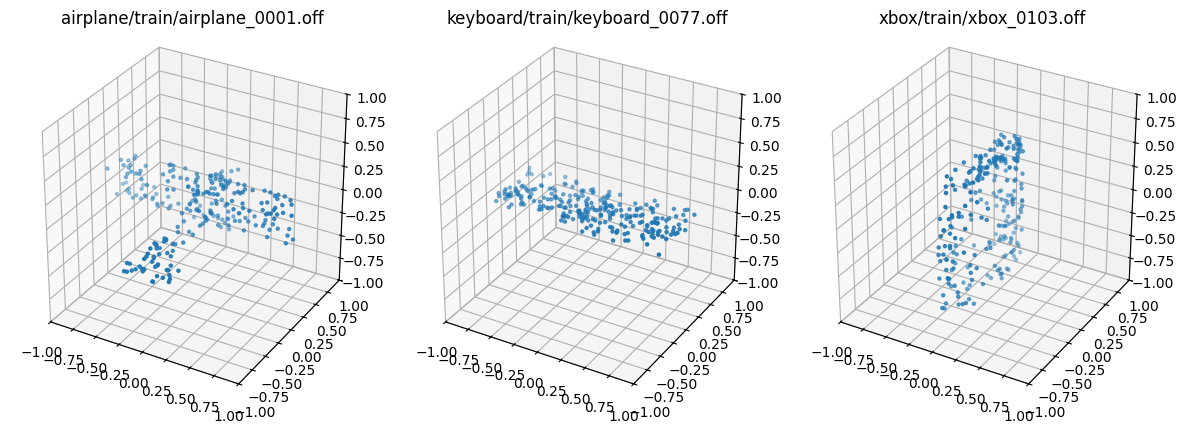

Q3.1 actual iteration-5 row-0 sum: 0.003906250931322575
Marginal target (comparison only): 0.00390625
q3_1 epoch 1: batch 100/1231
q3_1 epoch 1: batch 200/1231
q3_1 epoch 1: batch 300/1231
q3_1 epoch 1: batch 400/1231
q3_1 epoch 1: batch 500/1231
q3_1 epoch 1: batch 600/1231
q3_1 epoch 1: batch 700/1231
q3_1 epoch 1: batch 800/1231
q3_1 epoch 1: batch 900/1231
q3_1 epoch 1: batch 1000/1231
q3_1 epoch 1: batch 1100/1231
q3_1 epoch 1: batch 1200/1231
q3_1 epoch 1/20: reconstruction=0.118091, raw SWD=0.000000, total=0.118091
q3_1 epoch 2: batch 100/1231
q3_1 epoch 2: batch 200/1231
q3_1 epoch 2: batch 300/1231
q3_1 epoch 2: batch 400/1231
q3_1 epoch 2: batch 500/1231
q3_1 epoch 2: batch 600/1231
q3_1 epoch 2: batch 700/1231
q3_1 epoch 2: batch 800/1231
q3_1 epoch 2: batch 900/1231
q3_1 epoch 2: batch 1000/1231
q3_1 epoch 2: batch 1100/1231
q3_1 epoch 2: batch 1200/1231
q3_1 epoch 2/20: reconstruction=0.102629, raw SWD=0.000000, total=0.102629
q3_1 epoch 3: batch 100/1231
q3_1 epoch 3: bat

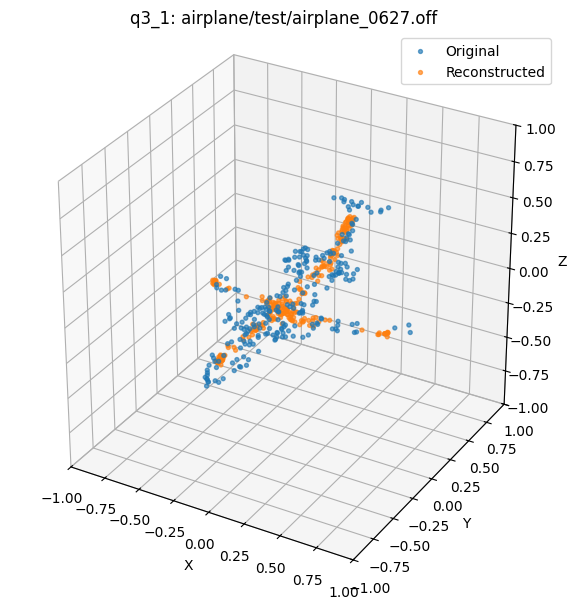

In [1]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import json
import math
import random
import hashlib
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 2026
DATA_ROOT =  Path('/kaggle/input/datasets/balraj98/modelnet40-princeton-3d-object-dataset/ModelNet40') 
OUTPUT_DIR = (Path('/kaggle/working') if Path('/kaggle/input').exists()
              else Path.cwd()) / 'ADRL_q3_outputs'
N_POINTS = 256
LATENT_DIM = 64
BATCH_SIZE = 8  # Conservative memory use for differentiating through 30 OT iterations.
EPOCHS_Q31 = 20  # Epoch count and batch size are implementation choices.
EPOCHS_Q32 = 20
EPSILON = 0.1
SINKHORN_STEPS = 30
N_DIRECTIONS = 50
LAMBDA_SWD = 1.0


def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)


set_seed()
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def read_off(path):
    # Handle both 'OFF\n8 6 0' and 'OFF8 6 0', plus blank/comment lines.
    with path.open() as stream:
        lines = (line.split('#', 1)[0].strip() for line in stream)
        lines = (line for line in lines if line)
        header = next(lines)
        if not header.startswith('OFF'):
            raise ValueError(f'{path}: expected an OFF mesh.')
        counts = (header[3:].strip() or next(lines)).split()
        n_vertices, n_faces = int(counts[0]), int(counts[1])
        vertices = np.array([list(map(float, next(lines).split()[:3]))
                             for _ in range(n_vertices)], dtype=np.float64)
        triangles = []
        for _ in range(n_faces):
            face = list(map(int, next(lines).split()))
            size, indices = face[0], face[1:1 + face[0]]
            if size < 3 or len(indices) != size:
                raise ValueError(f'{path}: invalid polygon.')
            if min(indices) < 0 or max(indices) >= n_vertices:
                raise ValueError(f'{path}: face index outside vertex array.')
            for j in range(1, size - 1):
                triangles.append([indices[0], indices[j], indices[j + 1]])
    if not triangles or not np.isfinite(vertices).all():
        raise ValueError(f'{path}: empty or nonfinite mesh.')
    return vertices, np.asarray(triangles, dtype=np.int64)


def surface_cloud(path, relative_name):
    vertices, faces = read_off(path)
    triangles = vertices[faces]
    area = 0.5 * np.linalg.norm(np.cross(triangles[:, 1] - triangles[:, 0],
                                       triangles[:, 2] - triangles[:, 0]), axis=1)
    good = np.isfinite(area) & (area > 0)
    triangles, area = triangles[good], area[good]
    if len(area) == 0 or not np.isfinite(area.sum()):
        raise ValueError(f'{path}: no usable surface area.')
    # Stable per-mesh RNG; sampling stays fixed across models and epochs.
    mesh_seed = int.from_bytes(hashlib.sha256(relative_name.encode()).digest()[:8], 'little')
    rng = np.random.default_rng([SEED, mesh_seed])
    selected = rng.choice(len(area), size=N_POINTS, p=area / area.sum())
    a, b, c = triangles[selected].transpose(1, 0, 2)
    r = np.sqrt(rng.random((N_POINTS, 1)))
    v = rng.random((N_POINTS, 1))
    cloud = (1 - r) * a + r * (1 - v) * b + r * v * c
    cloud -= cloud.mean(axis=0, keepdims=True)
    radius = np.linalg.norm(cloud, axis=1).max()
    if radius <= 0:
        raise ValueError(f'{path}: zero-radius cloud.')
    cloud = (cloud / radius).astype(np.float32)
    assert cloud.shape == (N_POINTS, 3) and np.isfinite(cloud).all()
    assert np.allclose(cloud.mean(0), 0, atol=1e-6)
    assert np.isclose(np.linalg.norm(cloud, axis=1).max(), 1, atol=1e-6)
    return cloud


def find_root():
    if DATA_ROOT is not None:
        root = Path(DATA_ROOT)
    else:
        base = Path('/kaggle/input') if Path('/kaggle/input').is_dir() else Path.cwd() / 'data'
        candidates = sorted({p.parent.parent.parent for p in base.rglob('*.off')
                             if p.parent.name == 'train'
                             and (p.parent.parent / 'test').is_dir()})
        if len(candidates) != 1:
            raise ValueError('Attach the extracted ModelNet40 OFF dataset and set DATA_ROOT. '
                             f'Found roots: {candidates}. HDF5 point clouds are not this guide\'s input.')
        root = candidates[0]
    if not list(root.glob('*/train/*.off')) or not list(root.glob('*/test/*.off')):
        raise ValueError(f'{root}: expected class/train/*.off and class/test/*.off.')
    return root


class ModelNetDataset(Dataset):
    def __init__(self, root, split):
        self.names = [p.relative_to(root).as_posix()
                      for p in sorted(root.glob(f'*/{split}/*.off'))]
        clouds = []
        for i, name in enumerate(self.names):
            clouds.append(surface_cloud(root / name, name))
            if (i + 1) % 500 == 0:
                print(f'{split}: sampled {i + 1}/{len(self.names)} meshes', flush=True)
        self.clouds = torch.from_numpy(np.stack(clouds))

    def __len__(self):
        return len(self.names)

    def __getitem__(self, index):
        return self.clouds[index], index


class SetAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.point_mlp = nn.Sequential(nn.Linear(3, 64), nn.ReLU(),
                                       nn.Linear(64, 128), nn.ReLU(),
                                       nn.Linear(128, 256), nn.ReLU())
        self.latent = nn.Linear(256, LATENT_DIM)
        self.decoder = nn.Sequential(nn.Linear(LATENT_DIM, 256), nn.ReLU(),
                                     nn.Linear(256, 512), nn.ReLU(),
                                     nn.Linear(512, N_POINTS * 3))

    def encode(self, x):
        # Shared MLP commutes with row permutation; max over rows is symmetric.
        # Therefore E(Pi X) = E(X). Never flatten points before pooling.
        features = self.point_mlp(x)
        return self.latent(features.max(dim=1).values)

    def decode(self, z):
        return self.decoder(z).reshape(-1, N_POINTS, 3)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z


def sinkhorn(x, y, steps=SINKHORN_STEPS, epsilon=EPSILON, capture_fifth=False):
    # C_ij = ||x_i-y_j||^2. All objects and point pairs are computed together.
    # P* minimizes <P,C> + epsilon sum(P log P), with uniform row/column masses.
    # Its positive-interior Hessian is epsilon*diag(1/P_ij), strictly positive.
    # This gives a unique positive plan for positive masses and finite costs.
    # Stationarity yields P_ij = u_i exp(-C_ij/epsilon) v_j (absorb constants).
    # With one redundant marginal constraint removed, the constrained Hessian
    # is invertible; the implicit-function theorem gives smooth dependence on C.
    # Finite unrolling is also differentiable: logsumexp, exp and sums are smooth.
    # Only a saved COPY is detached; training gradients pass through every update.
    cost = (x[:, :, None, :] - y[:, None, :, :]).square().sum(-1)
    log_kernel = -cost / epsilon
    log_a, log_b = -math.log(x.shape[1]), -math.log(y.shape[1])
    log_u = torch.zeros_like(x[:, :, 0])
    log_v = torch.zeros_like(y[:, :, 0])
    fifth = None
    # Log-domain scaling is algebraically u=a/(Kv), v=b/(K^T u),
    # but avoids kernel underflow. One iteration = one complete u THEN v update.
    for iteration in range(1, steps + 1):
        log_u = log_a - torch.logsumexp(log_kernel + log_v[:, None, :], dim=2)
        log_v = log_b - torch.logsumexp(log_kernel + log_u[:, :, None], dim=1)
        if capture_fifth and iteration == 5:
            fifth = (log_u[:, :, None] + log_kernel + log_v[:, None, :]).exp().detach().cpu()
    plan = (log_u[:, :, None] + log_kernel + log_v[:, None, :]).exp()
    # GUIDE's transport cost evaluated using the entropy-regularized plan.
    # No pointwise MSE, Chamfer, KL latent loss or debiased Sinkhorn divergence.
    loss = (plan * cost).sum(dim=(1, 2)).mean()
    return loss, plan, fifth


def make_loader(dataset):
    # Fresh generator for each model; inspection never consumes this loader.
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
                      pin_memory=device.type == 'cuda',
                      generator=torch.Generator().manual_seed(SEED))


def save_results(results):
    (OUTPUT_DIR / 'results.json').write_text(json.dumps(results, indent=2, allow_nan=False))


def train_model(dataset, results, use_swd=False):
    set_seed()
    model = SetAutoencoder().to(device)
    with torch.no_grad():
        example = dataset.clouds[:2].to(device)
        permutation = torch.randperm(N_POINTS, generator=torch.Generator().manual_seed(17)).to(device)
        assert torch.allclose(model.encode(example), model.encode(example[:, permutation]), atol=1e-6)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loader = make_loader(dataset)
    tag = 'q3_2' if use_swd else 'q3_1'
    epochs = EPOCHS_Q32 if use_swd else EPOCHS_Q31
    direction_rng = torch.Generator(device='cpu').manual_seed(SEED)
    prior_rng = torch.Generator(device='cpu').manual_seed(SEED + 1)
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        totals = np.zeros(3, dtype=np.float64)
        for batch_number, (x, indices) in enumerate(loader, start=1):
            x = x.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            reconstructed, z = model(x)
            capture = not use_swd and epoch == 1 and batch_number == 1
            reconstruction, plan, fifth = sinkhorn(x, reconstructed, capture_fifth=capture)
            if capture:
                assert fifth.shape == (len(x), N_POINTS, N_POINTS)
                assert torch.isfinite(fifth).all()
                # Actual float32 tensor reduction, saved at the requested moment.
                value = fifth[0, 0].sum().item()
                results['q3_1_transport_P_row0_sum_e1_b1_iter5'] = value
                torch.save(dict(P=fifth, row0_sum=value, epoch=1, batch=1, iterations=5,
                                files=[dataset.names[i] for i in indices.tolist()],
                                original=x.detach().cpu(), reconstructed=reconstructed.detach().cpu()),
                           OUTPUT_DIR / 'q3_1_transport_iter5.pt')
                save_results(results)
                print('Q3.1 actual iteration-5 row-0 sum:', repr(value), flush=True)
                print('Marginal target (comparison only):', 1 / N_POINTS)
            swd = z.new_zeros(())
            if use_swd:
                prior = torch.randn(z.shape, generator=prior_rng).to(device)
                directions_cpu = sample_directions(direction_rng)
                directions = directions_cpu.to(device)
                if epoch == 1 and batch_number == 1:
                    value = directions_cpu[0, 0].item()
                    results['q3_2_first_unit_direction_dim0'] = value
                    torch.save(dict(directions=directions_cpu, first_component=value,
                                    direction_seed=SEED, rng_device='cpu',
                                    prior=prior.detach().cpu(), latent=z.detach().cpu()),
                               OUTPUT_DIR / 'q3_2_first_directions.pt')
                    save_results(results)
                    print('Q3.2 first unit direction, first component:', repr(value), flush=True)
                swd = sliced_wasserstein(z, prior, directions)
            loss = reconstruction + LAMBDA_SWD * swd
            if not torch.isfinite(loss).item():
                raise FloatingPointError(f'{tag}: nonfinite loss.')
            loss.backward()
            grads = [p.grad for p in model.parameters()]
            if any(g is None for g in grads) or not torch.stack([torch.isfinite(g).all() for g in grads]).all().item():
                raise FloatingPointError(f'{tag}: missing or nonfinite gradient.')
            optimizer.step()
            totals += np.array([reconstruction.item(), swd.item(), loss.item()]) * len(x)
            if batch_number % 100 == 0:
                print(f'{tag} epoch {epoch}: batch {batch_number}/{len(loader)}', flush=True)
        row = dict(epoch=epoch, reconstruction=totals[0] / len(dataset),
                   raw_swd=totals[1] / len(dataset), total=totals[2] / len(dataset))
        history.append(row)
        print(f'{tag} epoch {epoch}/{epochs}: reconstruction={row["reconstruction"]:.6f}, '
              f'raw SWD={row["raw_swd"]:.6f}, total={row["total"]:.6f}', flush=True)
        torch.save(dict(model=model.state_dict(), optimizer=optimizer.state_dict(),
                        history=history, n_points=N_POINTS, latent_dim=LATENT_DIM,
                        epsilon=EPSILON, sinkhorn_steps=SINKHORN_STEPS), OUTPUT_DIR / f'{tag}_model.pt')
        (OUTPUT_DIR / f'{tag}_history.json').write_text(json.dumps(history, indent=2))
    return model, history


def plot_overlay(model, dataset, tag):
    model.eval()
    original = dataset.clouds[:1].to(device)
    with torch.no_grad():
        reconstructed, _ = model(original)
        # Dedicated RNG: this check cannot change the required training order.
        permutation = torch.randperm(N_POINTS, generator=torch.Generator().manual_seed(17))
        error = (model.encode(original) - model.encode(original[:, permutation.to(device)])).abs().max().item()
    if error > 1e-6:
        raise AssertionError(f'Encoder is not permutation invariant: {error}')
    print('Encoder permutation maximum error:', error)
    x, y = original[0].cpu().numpy(), reconstructed[0].cpu().numpy()
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(*x.T, s=8, alpha=0.65, label='Original')
    ax.scatter(*y.T, s=8, alpha=0.65, label='Reconstructed')
    limit = float(max(np.abs(x).max(), np.abs(y).max(), 1))
    ax.set(xlim=(-limit, limit), ylim=(-limit, limit), zlim=(-limit, limit),
           xlabel='X', ylabel='Y', zlabel='Z', title=f'{tag}: {dataset.names[0]}')
    ax.set_box_aspect((1, 1, 1))
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f'{tag}_overlay.png', dpi=130)
    plt.show()
    plt.close(fig)
    torch.save(dict(original=original.cpu(), reconstructed=reconstructed.cpu(),
                    file=dataset.names[0], permutation_error=error), OUTPUT_DIR / f'{tag}_overlay.pt')


def run_q31():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    root = find_root()
    print('Device:', device, '| Dataset:', root, flush=True)
    if device.type == 'cpu':
        print('For faster training, select a Kaggle GPU accelerator.', flush=True)
    train_data, test_data = ModelNetDataset(root, 'train'), ModelNetDataset(root, 'test')
    fig = plt.figure(figsize=(12, 4))
    for panel, index in enumerate(np.linspace(0, len(train_data) - 1, min(3, len(train_data)), dtype=int), 1):
        ax = fig.add_subplot(1, 3, panel, projection='3d')
        ax.scatter(*train_data.clouds[index].numpy().T, s=5)
        ax.set(title=train_data.names[index], xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1))
        ax.set_box_aspect((1, 1, 1))
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'sampled_clouds_preview.png', dpi=130)
    plt.show()
    plt.close(fig)
    # Store the exact sampled sets and file order once for audit/reuse.
    torch.save(dict(train=train_data.clouds, test=test_data.clouds,
                    train_files=train_data.names, test_files=test_data.names), OUTPUT_DIR / 'sampled_clouds.pt')
    audit = dict(seed=SEED, dataset='ModelNet40 OFF meshes (GUIDE substitution)',
                 root=str(root), train_count=len(train_data), test_count=len(test_data),
                 n_points=N_POINTS, latent_dim=LATENT_DIM, batch_size=BATCH_SIZE,
                 epochs_q31=EPOCHS_Q31, epochs_q32=EPOCHS_Q32, epsilon=EPSILON,
                 sinkhorn_steps=SINKHORN_STEPS, lambda_swd=LAMBDA_SWD,
                 torch_version=torch.__version__, numpy_version=np.__version__,
                 device=str(device), direction_rng='CPU torch.Generator, seed 2026',
                 prior_rng='separate CPU torch.Generator, seed 2027',
                 gpu=torch.cuda.get_device_name(0) if device.type == 'cuda' else None)
    (OUTPUT_DIR / 'data_audit.json').write_text(json.dumps(audit, indent=2))
    results = {}
    model, history = train_model(train_data, results)
    plot_overlay(model, test_data, 'q3_1')
    return train_data, test_data, results


if __name__ == '__main__':
    train_data, test_data, results = run_q31()



Q3.2 first unit direction, first component: -0.02479434385895729
q3_2 epoch 1: batch 100/1231
q3_2 epoch 1: batch 200/1231
q3_2 epoch 1: batch 300/1231
q3_2 epoch 1: batch 400/1231
q3_2 epoch 1: batch 500/1231
q3_2 epoch 1: batch 600/1231
q3_2 epoch 1: batch 700/1231
q3_2 epoch 1: batch 800/1231
q3_2 epoch 1: batch 900/1231
q3_2 epoch 1: batch 1000/1231
q3_2 epoch 1: batch 1100/1231
q3_2 epoch 1: batch 1200/1231
q3_2 epoch 1/20: reconstruction=0.124311, raw SWD=0.591303, total=0.715614
q3_2 epoch 2: batch 100/1231
q3_2 epoch 2: batch 200/1231
q3_2 epoch 2: batch 300/1231
q3_2 epoch 2: batch 400/1231
q3_2 epoch 2: batch 500/1231
q3_2 epoch 2: batch 600/1231
q3_2 epoch 2: batch 700/1231
q3_2 epoch 2: batch 800/1231
q3_2 epoch 2: batch 900/1231
q3_2 epoch 2: batch 1000/1231
q3_2 epoch 2: batch 1100/1231
q3_2 epoch 2: batch 1200/1231
q3_2 epoch 2/20: reconstruction=0.110351, raw SWD=0.541271, total=0.651622
q3_2 epoch 3: batch 100/1231
q3_2 epoch 3: batch 200/1231
q3_2 epoch 3: batch 300/1

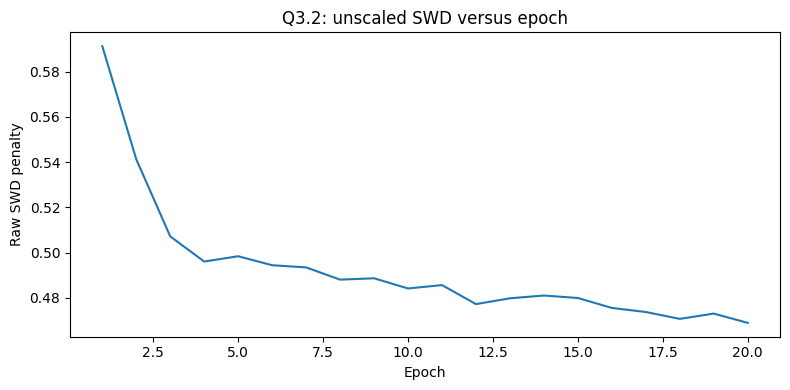

Encoder permutation maximum error: 0.0


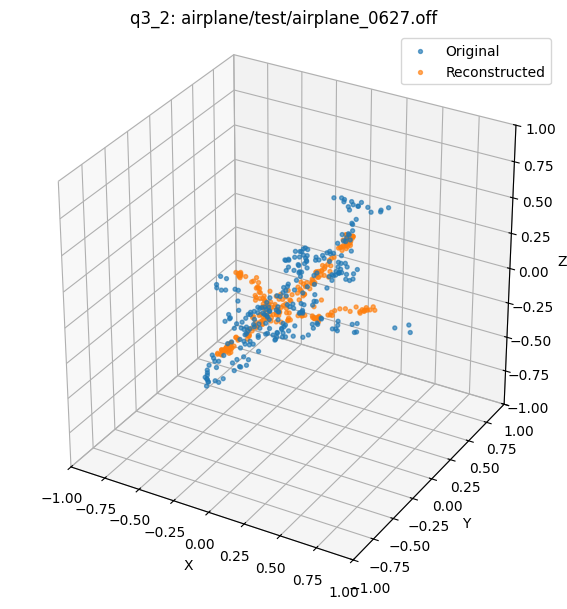

{
  "q3_1_transport_P_row0_sum_e1_b1_iter5": 0.003906250931322575,
  "q3_2_first_unit_direction_dim0": -0.02479434385895729
}
Saved outputs: /kaggle/working/ADRL_q3_outputs


In [2]:
def sample_directions(generator):
    gaussian = torch.randn(N_DIRECTIONS, LATENT_DIM, generator=generator)
    norms = torch.linalg.vector_norm(gaussian, dim=1, keepdim=True)
    if (norms == 0).any():
        raise FloatingPointError('Unexpected zero Gaussian direction.')
    directions = gaussian / norms
    assert directions.shape == (50, LATENT_DIM)
    assert torch.allclose(directions.norm(dim=1), torch.ones(50), atol=1e-6)
    return directions


def sliced_wasserstein(z, prior, directions):
    encoded_projection = z @ directions.T  # [B,50]
    prior_projection = prior @ directions.T
    encoded_sorted = encoded_projection.sort(dim=0).values  # Sort over samples.
    prior_sorted = prior_projection.sort(dim=0).values
    return (encoded_sorted - prior_sorted).square().mean()


def run_q32(train_data, test_data, results):
    model, history = train_model(train_data, results, use_swd=True)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot([row['epoch'] for row in history], [row['raw_swd'] for row in history])
    ax.set(xlabel='Epoch', ylabel='Raw SWD penalty', title='Q3.2: unscaled SWD versus epoch')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'q3_2_raw_swd.png', dpi=130)
    plt.show()
    plt.close(fig)
    plot_overlay(model, test_data, 'q3_2')
    save_results(results)
    print(json.dumps(results, indent=2))
    print('Saved outputs:', OUTPUT_DIR)


if __name__ == '__main__':
    assert 'train_data' in globals(), 'Run the Q3.1 cell first.'
    run_q32(train_data, test_data, results)
